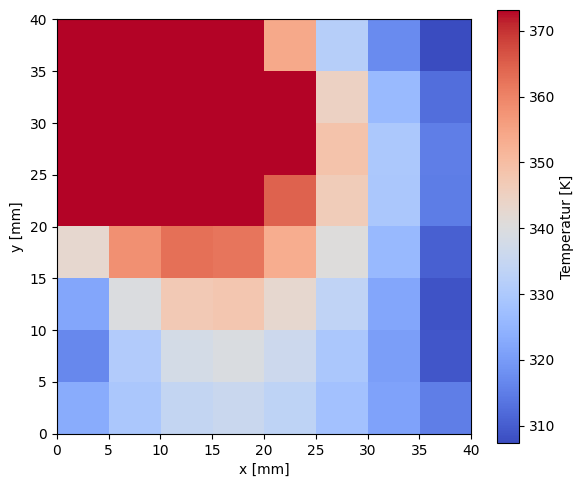

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import time



def solve_temperature(n, L=40e-3, T_source=373.15):
    dx = L / n
    dy = dx
    N = n * n
    L_mm = L * 1e3

    #  Materiale und parameter
    k_holz   = 0.10       #   Holz
    k_gips   = 0.20       #  Gips
    k_silber = 430.0      #  Silber
    h_holz   = 23.0       # W/m^2k  Wärmeübergangskoeffizient
    T_inf    = 294.15     # 21°C Raumtemperatur

    idx = lambda i, j: i * n + j
    def harmonic(k1, k2):
        s = k1 + k2
        return 0.0 if s == 0 else 2.0 * k1 * k2 / s

    # Geometrie
    k = np.full((n, n), k_holz, dtype=float)   # Standard = Holz
    i_D, j_D = n//2 , n//2
    k[:i_D, :j_D] = k_silber                 # links oben = Silber
    k[:i_D, j_D:] = k_gips                   # rechts oben = Gips

    # Dirichlet-Wärmequellen oben in der Mitte
    hot_pts_1based = [(n//4, n//2), (n//4, n//2+1), (n//4+1, n//2+1), (n//4+1, n//2+1)]
    hot_pts = [(r-1, c-1) for (r, c) in hot_pts_1based]

    dirichlet_mask = np.zeros_like(k, dtype=bool)
    for (ii, jj) in hot_pts:
        if 0 <= ii < n and 0 <= jj < n:
            dirichlet_mask[ii, jj] = True
        else:
            raise ValueError(f"Wärmequelle außerhalb des Bereichs: {(ii, jj)} für n={n}")

    # Sparse-Matrix Aufbau
    rows, cols, data = [], [], []
    S = sp.lil_matrix((N, 1))

    for i in range(n):
        for j in range(n):
            p = idx(i, j)

            # Dirichlet-Bedingung: Wärmequelle
            if dirichlet_mask[i, j]:
                rows.append(p); cols.append(p); data.append(1.0)
                S[p, 0] = T_source
                continue

            # Leitwerte zu Nachbarn
            kE = harmonic(k[i, j], k[i, j + 1]) if j < n - 1 else 0.0
            kW = harmonic(k[i, j], k[i, j - 1]) if j > 0     else 0.0
            kN = harmonic(k[i - 1, j], k[i, j]) if i > 0     else 0.0
            kS = harmonic(k[i, j], k[i + 1, j]) if i < n - 1 else 0.0

            aE, aW, aN, aS = kE, kW, kN, kS
            aP = aE + aW + aN + aS

            if j < n - 1:
                rows.append(p); cols.append(idx(i, j + 1)); data.append(-aE)
            if j > 0:
                rows.append(p); cols.append(idx(i, j - 1)); data.append(-aW)
            if i > 0:
                rows.append(p); cols.append(idx(i - 1, j)); data.append(-aN)
            if i < n - 1:
                rows.append(p); cols.append(idx(i + 1, j)); data.append(-aS)

            # Cauchy-Randbedingung

                if i == 0:       # Nordrand
                    a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf
                if i == n - 1:   # Südrand
                    a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf
                if j == 0:       # Westrand
                    a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf
                if j == n - 1:   # Ostrand
                    a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf

            # Diagonale
            rows.append(p); cols.append(p); data.append(aP)

    #Solve
    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    T_vec = spla.spsolve(A, S.tocsr())
    T_field = T_vec.reshape((n, n))
    return T_field

# Plot
if __name__ == "__main__":
    n = 8
    L = 40e-3
    T = solve_temperature(n, L=L, T_source=373.15)

    L_mm = L * 1e3
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(T, origin="upper", extent=[0, L_mm, 0, L_mm],
                   interpolation="nearest", cmap="coolwarm")
    cbar = fig.colorbar(im, ax=ax); cbar.set_label("Temperatur [K]")
    ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]")
    ax.set_aspect("equal")
    plt.tight_layout(); plt.show()



s values: [3, 4, 5, 6, 7, 8]
Absolute errors: [np.float64(35.66813725699783), np.float64(0.3101280279907428), np.float64(0.20762241843226548), np.float64(0.12814194364618742), np.float64(0.061069878293676536), np.float64(0.0)]
Relative errors: [np.float64(0.0957088714156468), np.float64(0.0008321728795357061), np.float64(0.0005571175832563502), np.float64(0.00034384600833800116), np.float64(0.00016387011978061857), np.float64(0.0)]
Compute times [s]: [0.002417325973510742, 0.003017902374267578, 0.010856389999389648, 0.04177546501159668, 0.206712007522583, 0.9890220165252686]


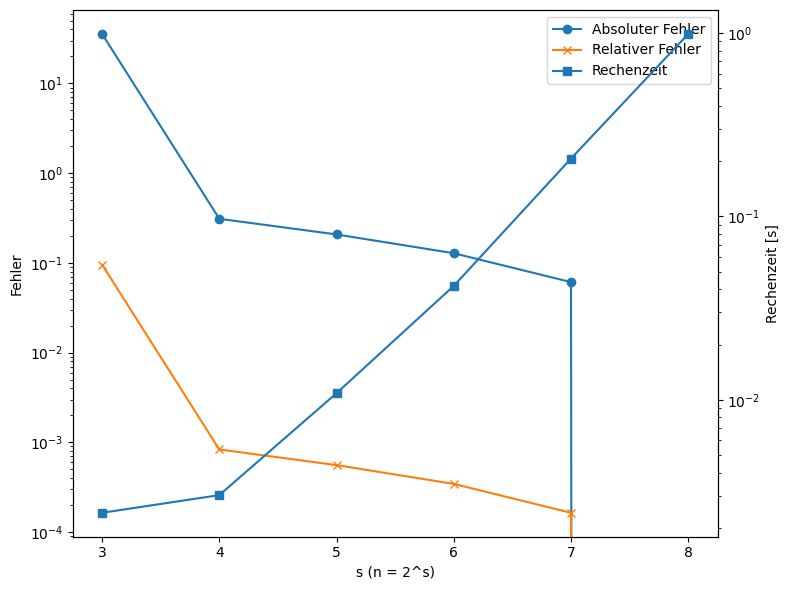

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

def grid_analysis(L=40e-3, ref_points=None):
    if ref_points is None:
        n = 8
        ref_points = [
            (1, 1),
            (1, n-2),
            (n-2, 1),
            (n-2, n-3),
            (n//2, 3*n//4)
        ]

    # Gittergrößen: n = 2^s
    s_list = list(range(3, 9))          # s = 3...8
    n_list = [2**s for s in s_list]     # n = 8,16,32,64,128,256

    # Referenzlösung
    n_ref = n_list[-1]
    T_ref = solve_temperature(n_ref, L)

    absolute_errors = []
    relative_errors = []
    compute_times = []

    for n in n_list:
        start_time = time.time()
        T = solve_temperature(n, L)
        end_time = time.time()
        compute_time = end_time - start_time

        abs_error = []
        rel_error = []

        for (i, j) in ref_points:
            T_ref_point = T_ref[i, j]
            T_point = T[i, j]
            abs_error.append(abs(T_point - T_ref_point))
            rel_error.append(abs(T_point - T_ref_point) /T_ref_point )

        absolute_errors.append(np.mean(abs_error))
        relative_errors.append(np.mean(rel_error))
        compute_times.append(compute_time)

    return s_list, absolute_errors, relative_errors, compute_times


# Plot
s_list, abs_errors, rel_errors, compute_times = grid_analysis()
print("s values:", s_list)
print("Absolute errors:", abs_errors)
print("Relative errors:", rel_errors)
print("Compute times [s]:", compute_times)

fig, ax1 = plt.subplots(figsize=(8, 6))

# y-Achse links
ax1.set_xlabel("s (n = 2^s)")
ax1.set_ylabel("Fehler")
l1, = ax1.semilogy(s_list, abs_errors, label="Absoluter Fehler", marker='o')
l2, = ax1.semilogy(s_list, rel_errors, label="Relativer Fehler", marker='x')

# y-Achse rechts
ax2 = ax1.twinx()
ax2.set_ylabel("Rechenzeit [s]")
l3, = ax2.semilogy(s_list, compute_times, label="Rechenzeit", marker='s')


lines = [l1, l2, l3]
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc="upper right")


plt.tight_layout()
plt.show()



dx = dy = 5.0000e-03 m
alpha(Silber) = 1.541e-04
dt_max = 4.054523e-02 s


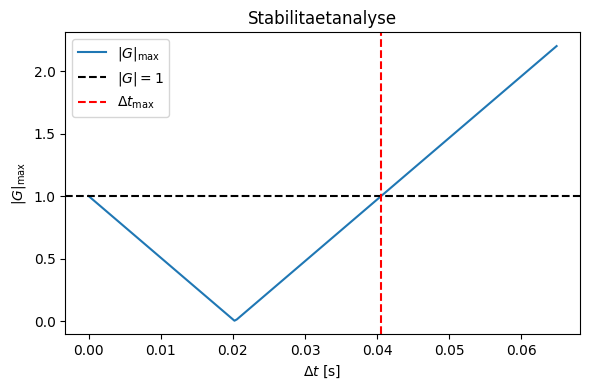

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def alpha_from(k, rho, cp):
    return k / (rho * cp)

def dt_max_explicit_2d(dx, dy, alpha):
    return 1.0 / (2.0 * alpha * (1.0/dx**2 + 1.0/dy**2))

def plot_Gmax_vs_dt(dx, dy, alpha, dt_max, save_path=None):
    factor = 4.0 * alpha * (1.0/dx**2 + 1.0/dy**2)
    dt_vals = np.linspace(0.0, 1.6*dt_max, 200)
    Gmax = np.abs(1.0 - factor * dt_vals)

    plt.figure(figsize=(6,4))
    plt.plot(dt_vals, Gmax, label=r'$|G|_{\max}$')
    plt.axhline(1.0, ls='--', color='k', label=r'$|G|=1$')
    plt.axvline(dt_max, ls='--', color='r', label=r'$\Delta t_{\max}$')
    plt.xlabel(r'$\Delta t$ [s]')
    plt.ylabel(r'$|G|_{\max}$')
    plt.title('Stabilitaetanalyse')
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_stability_analysis_silver():
    n = 8
    L = 40e-3
    dx = dy = L / n
    k_silver   = 380.0
    rho_silver = 10490.0
    cp_silver  = 235.0
    alpha_silver = alpha_from(k_silver, rho_silver, cp_silver)
    dt_max = dt_max_explicit_2d(dx, dy, alpha_silver)

    print("dx = dy = %.4e m" % dx)
    print("alpha(Silber) = %.3e" % alpha_silver)
    print("dt_max = %.6e s" % dt_max)

    plot_Gmax_vs_dt(dx, dy, alpha_silver, dt_max)

if __name__ == "__main__":
    run_stability_analysis_silver()

In [4]:
# Lars
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import time

In [5]:

# HA4.1. Lars
# ---------- Solver (unterstützt n == 1) ----------
def solve_temperature(n, L=40e-3, T_source=373.15):
    """
    Stationäre Temperaturlösung auf n×n-Gitter.
    Sonderfall n==1: 1x1-Zelle mit Dirichlet-Quelle -> T = T_source.
    """
    # --- n==1: 1x1-System mit Dirichlet-Quelle ---
    if n == 1:
        return np.array([[T_source]], dtype=float)

    dx = L / n
    N  = n * n

    # Material- und Randparameter
    k_holz   = 0.10
    k_gips   = 0.20
    k_silber = 430.0
    h_holz   = 23.0
    T_inf    = 294.15

    idx = lambda i, j: i * n + j
    def harmonic(k1, k2):
        s = k1 + k2
        return 0.0 if s == 0 else 2.0 * k1 * k2 / s

    # Geometrie
    k = np.full((n, n), k_holz, dtype=float)
    i_D, j_D = n//2, n//2
    k[:i_D, :j_D] = k_silber
    k[:i_D, j_D:] = k_gips

    # robuste Dirichlet-Quelle (2x2-Block, bei kleinen n automatisch gekappt)
    r0 = max(0, min(n-1, n//4))
    c0 = max(0, min(n-1, n//2))
    hot_pts = set()
    for di, dj in [(0,0),(0,1),(1,0),(1,1)]:
        ii, jj = r0+di, c0+dj
        if 0 <= ii < n and 0 <= jj < n:
            hot_pts.add((ii, jj))
    if not hot_pts:
        hot_pts.add((n//2, n//2))

    dirichlet_mask = np.zeros((n, n), dtype=bool)
    for (ii, jj) in hot_pts:
        dirichlet_mask[ii, jj] = True

    # Sparse-Aufbau
    rows, cols, data = [], [], []
    S = sp.lil_matrix((N, 1))

    for i in range(n):
        for j in range(n):
            p = idx(i, j)

            # Dirichlet-Zelle
            if dirichlet_mask[i, j]:
                rows.append(p); cols.append(p); data.append(1.0)
                S[p, 0] = T_source
                continue

            # Leitwerte
            kE = harmonic(k[i, j], k[i, j + 1]) if j < n - 1 else 0.0
            kW = harmonic(k[i, j], k[i, j - 1]) if j > 0     else 0.0
            kN = harmonic(k[i - 1, j], k[i, j]) if i > 0     else 0.0
            kS = harmonic(k[i, j], k[i + 1, j]) if i < n - 1 else 0.0

            aE, aW, aN, aS = kE, kW, kN, kS
            aP = aE + aW + aN + aS

            if j < n - 1:
                rows.append(p); cols.append(idx(i, j + 1)); data.append(-aE)
            if j > 0:
                rows.append(p); cols.append(idx(i, j - 1)); data.append(-aW)
            if i > 0:
                rows.append(p); cols.append(idx(i - 1, j)); data.append(-aN)
            if i < n - 1:
                rows.append(p); cols.append(idx(i + 1, j)); data.append(-aS)

            # Cauchy-Rand (korrekte Einrückung)
            if i == 0:
                a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf
            if i == n - 1:
                a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf
            if j == 0:
                a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf
            if j == n - 1:
                a_c = h_holz * dx; aP += a_c; S[p, 0] += a_c * T_inf

            rows.append(p); cols.append(p); data.append(aP)

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    T_vec = spla.spsolve(A, S.tocsr())
    return T_vec.reshape((n, n))


In [6]:
# Lars
# ---------- Gitteranalyse s=0..3, inkl. s=0-Zeit ----------
def grid_analysis(L=40e-3, s_min=0, s_max=3):
    s_list = list(range(s_min, s_max+1))     # [0,1,2,3]
    n_list = [2**s for s in s_list]          # [1,2,4,8]

    # Referenzgitter = feinstes (s_max)
    n_ref = n_list[-1]
    T_ref = solve_temperature(n_ref, L)

    # Referenzpunkte auf feinstem Gitter
    ref_points = [
        (1, 1),
        (1, n_ref-2),
        (n_ref-2, 1),
        (n_ref-2, n_ref-2),
        (n_ref//2, 3*n_ref//4)
    ]

    abs_errors, rel_errors, times = [], [], []

    for n in n_list:
        t0 = time.time()
        T  = solve_temperature(n, L)
        t1 = time.time()

        # Fehler an skalierten Punkten gegen T_ref
        errs_abs, errs_rel = [], []
        for (i_ref, j_ref) in ref_points:
            i = int(round(i_ref * n / n_ref))
            j = int(round(j_ref * n / n_ref))
            i = min(max(i, 0), n-1)
            j = min(max(j, 0), n-1)
            Tr = T_ref[i_ref, j_ref]
            Tp = T[i, j]
            errs_abs.append(abs(Tp - Tr))
            errs_rel.append(abs(Tp - Tr) / max(1e-12, Tr))

        abs_errors.append(float(np.mean(errs_abs)))
        rel_errors.append(float(np.mean(errs_rel)))
        times.append(float(t1 - t0))

    return s_list, abs_errors, rel_errors, times


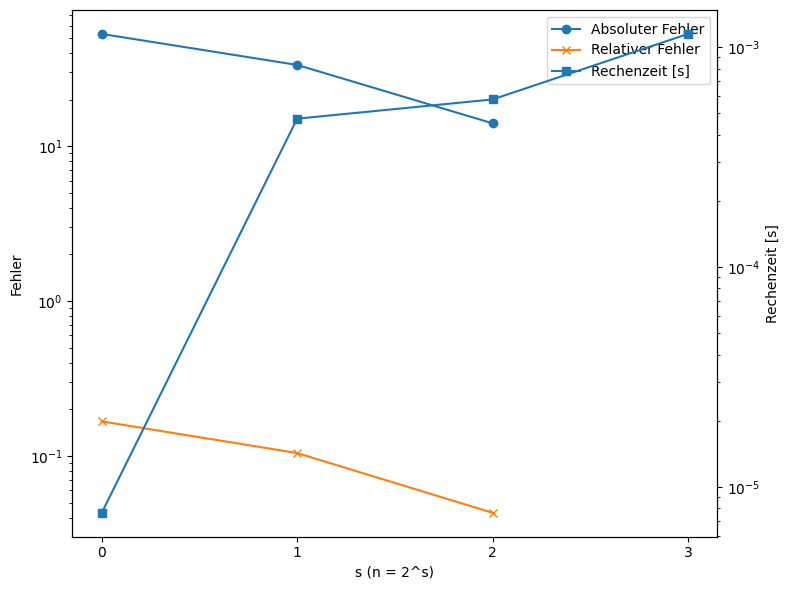

In [7]:
# Lars
# ---------- Plot: s=0..3, s=3-Zeit ausblenden, ganzzahlige x-Ticks ----------
s_list, abs_errors, rel_errors, compute_times = grid_analysis(s_min=0, s_max=3)

# s=3-Zeit ggf. aus Plot ausschließen (setze NaN, damit nicht gezeichnet)
if len(compute_times) >= 4 and compute_times[-1] == 0.0:
    compute_times[-1] = np.nan

fig, ax1 = plt.subplots(figsize=(8, 6))
l1, = ax1.semilogy(s_list[0:-1], abs_errors[0:-1], marker='o', label="Absoluter Fehler")
l2, = ax1.semilogy(s_list[0:-1], rel_errors[0:-1], marker='x', label="Relativer Fehler")
ax1.set_xlabel("s (n = 2^s)")
ax1.set_ylabel("Fehler")
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # ganze Zahlen

ax2 = ax1.twinx()
l3, = ax2.semilogy(s_list, compute_times, marker='s', label="Rechenzeit [s]")
ax2.set_ylabel("Rechenzeit [s]")

lines = [l1, l2, l3]
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc="upper right")
plt.tight_layout()
plt.show()


c:\Users\Lars\Documents\GitHub\FEM\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


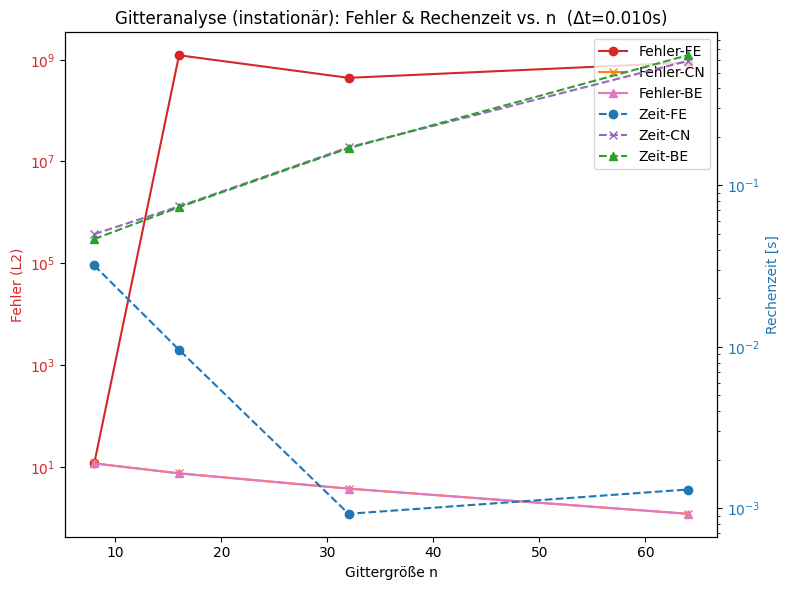

In [8]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import time



def _build_fields_transient(n, L=40e-3, T_source=373.15):
    # Wärmeleitfähigkeiten
    k_holz, k_gips, k_silber = 0.10, 0.20, 430.0
    # Dichte & Wärmekapazität
    rho_holz,  cp_holz   = 600.0, 1600.0
    rho_gips,  cp_gips   = 1150.0, 1090.0
    rho_silber,cp_silber = 10490.0, 235.0

    k   = np.full((n, n), k_holz,  dtype=float)
    rho = np.full((n, n), rho_holz, dtype=float)
    cp  = np.full((n, n), cp_holz,  dtype=float)

    i_D, j_D = n//2, n//2
    # links oben Silber, rechts oben Gips, unten Holz
    k[:i_D, :j_D]   = k_silber; rho[:i_D, :j_D]   = rho_silber; cp[:i_D, :j_D]   = cp_silber
    k[:i_D, j_D:]   = k_gips;   rho[:i_D, j_D:]   = rho_gips;   cp[:i_D, j_D:]   = cp_gips

    # 2x2 Dirichlet-Wärmequelle oben in der Mitte
    hot_pts = [(n//4-1, n//2-1), (n//4-1, n//2),
               (n//4,   n//2-1), (n//4,   n//2)]
    dirichlet_mask = np.zeros_like(k, dtype=bool)
    for (ii, jj) in hot_pts:
        if 0 <= ii < n and 0 <= jj < n:
            dirichlet_mask[ii, jj] = True
    return k, rho, cp, dirichlet_mask


def _assemble_K_S(n, L, k, h, T_inf, dirichlet_mask, T_source):
    """Assemblierung von K (Leitung) und S (Cauchy-Rand + Quelle) für transiente Schritte."""
    dx = L / n
    N  = n * n
    idx = lambda i, j: i * n + j

    def harmonic(k1, k2):
        s = k1 + k2
        return 0.0 if s == 0 else 2.0 * k1 * k2 / s

    rows, cols, data = [], [], []
    S = sp.lil_matrix((N, 1))

    for i in range(n):
        for j in range(n):
            p = idx(i, j)

            # Dirichlet: feste Temperatur
            if dirichlet_mask[i, j]:
                rows.append(p); cols.append(p); data.append(1.0)
                S[p, 0] = T_source
                continue

            # Leitwerte zu Nachbarn
            kE = harmonic(k[i, j], k[i, j+1]) if j < n-1 else 0.0
            kW = harmonic(k[i, j], k[i, j-1]) if j > 0    else 0.0
            kN = harmonic(k[i-1, j], k[i, j]) if i > 0    else 0.0
            kS = harmonic(k[i, j], k[i+1, j]) if i < n-1  else 0.0

            aE, aW, aN, aS = kE, kW, kN, kS
            aP = aE + aW + aN + aS

            if j < n-1: rows.append(p); cols.append(idx(i, j+1)); data.append(-aE)
            if j > 0:   rows.append(p); cols.append(idx(i, j-1)); data.append(-aW)
            if i > 0:   rows.append(p); cols.append(idx(i-1, j)); data.append(-aN)
            if i < n-1: rows.append(p); cols.append(idx(i+1, j)); data.append(-aS)

            # Cauchy-Randbedingung
            if i == 0:     a_c = h*dx; aP += a_c; S[p, 0] += a_c*T_inf
            if i == n-1:   a_c = h*dx; aP += a_c; S[p, 0] += a_c*T_inf
            if j == 0:     a_c = h*dx; aP += a_c; S[p, 0] += a_c*T_inf
            if j == n-1:   a_c = h*dx; aP += a_c; S[p, 0] += a_c*T_inf

            rows.append(p); cols.append(p); data.append(aP)

    K = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    return K, S.tocsr()


def _capacity_diag(n, L, rho, cp, dirichlet_mask):
    """Diagonale von C: rho*cp*Zellenfläche; für Dirichlet-Zellen 0."""
    dx = L / n
    area = dx*dx
    N = n * n
    Cdiag = np.zeros(N)
    idx = lambda i, j: i * n + j
    for i in range(n):
        for j in range(n):
            Cdiag[idx(i, j)] = 0.0 if dirichlet_mask[i, j] else rho[i, j]*cp[i, j]*area
    return Cdiag




def _step_theta(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init, gamma):
    """
    Allgemeine θ-Methode:
        (C/dt + γ K) T^{n+1} = (C/dt) T^{n} + S - (1-γ) K T^{n}
    gamma=0   -> Explizit (FE)
    gamma=0.5 -> Crank–Nicolson (CN)
    gamma=1   -> Implizit (BE)
    """
    N = n * n
    Tn = np.full(N, T_init)

    mask_flat = dirichlet_mask.ravel()
    Tn[mask_flat] = T_source

    steps = int(round(T_end / dt))
    Svec  = S.toarray().ravel()
    C_over_dt = sp.diags(Cdiag / dt)

    if gamma == 0.0:
        # Explizit: nur Vektor-Updates
        nz = Cdiag > 0
        for _ in range(steps):
            rhs = Svec - K.dot(Tn)                       # F(Tn) im expliziten Fall
            Tn[nz] += (dt / Cdiag[nz]) * rhs[nz]
            Tn[mask_flat] = T_source                     # Dirichlet hart setzen
            if not np.isfinite(Tn).all() or np.max(np.abs(Tn)) > 1e10:
                break
    else:
        # Implizit/CN: B fix faktorisiert
        B = C_over_dt + gamma * K
        solve = spla.factorized(B)
        for _ in range(steps):
            rhs = C_over_dt.dot(Tn) + Svec - (1.0 - gamma) * K.dot(Tn)
            Tn  = solve(rhs)
            Tn[mask_flat] = T_source
            if not np.isfinite(Tn).all() or np.max(np.abs(Tn)) > 1e10:
                break

    return Tn.reshape(n, n)


def _step_FE(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init):
    return _step_theta(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init, gamma=0.0)

def _step_CN(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init):
    return _step_theta(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init, gamma=0.5)

def _step_BE(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init):
    return _step_theta(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init, gamma=1.0)


#  Fehler (gegen Referenz)

def _make_points(L, m=9):
    xs = np.linspace(0.05*L, 0.95*L, m)
    ys = np.linspace(0.05*L, 0.95*L, m)
    return [(x, y) for y in ys for x in xs]

def _bilinear_sample(T, n, L, x, y):
    dx = L / n
    j_f = x/dx - 0.5
    i_f = y/dx - 0.5
    i0 = int(np.floor(i_f)); j0 = int(np.floor(j_f))
    i0 = max(0, min(n-1, i0)); j0 = max(0, min(n-1, j0))
    i1 = max(0, min(n-1, i0+1)); j1 = max(0, min(n-1, j0+1))
    di = i_f - i0; dj = j_f - j0
    Q11, Q12 = T[i0, j0], T[i0, j1]
    Q21, Q22 = T[i1, j0], T[i1, j1]
    return (Q11*(1-di)*(1-dj) + Q12*(1-di)*dj + Q21*di*(1-dj) + Q22*di*dj)

def _L2_error_vs_ref(T, n, L, T_ref, n_ref, L_ref, points):
    vals = []
    for (x, y) in points:
        t  = _bilinear_sample(T,     n,     L,     x, y)
        tr = _bilinear_sample(T_ref, n_ref, L_ref, x, y)
        vals.append(abs(t - tr))
    vals = np.asarray(vals)
    if not np.isfinite(vals).all():
        return np.nan
    return float(np.sqrt(np.mean(vals**2)))


# Plot

def compare_three_methods_one_figure():
    # Parameter
    T_end  = 10.0
    T_inf  = 21.0 + 273.15
    T_src  = 100.0 + 273.15
    T_init = T_inf
    h      = 23.0
    L      = 40e-3

    # Gittergrößen (128 nur als Referenz)
    n_list = [8, 16, 32, 64]

    # Zeitschritt (Varable)
    dt_fixed = 0.01

    # Referenzlösung: n_ref=128, dt_ref=0.001 (BE) bei t=10s
    n_ref, dt_ref = 128, 0.001
    k_ref, rho_ref, cp_ref, mask_ref = _build_fields_transient(n_ref, L, T_src)
    K_ref, S_ref = _assemble_K_S(n_ref, L, k_ref, h, T_inf, mask_ref, T_src)
    Cdiag_ref    = _capacity_diag(n_ref, L, rho_ref, cp_ref, mask_ref)
    T_ref = _step_BE(n_ref, L, T_end, dt_ref, K_ref, S_ref, Cdiag_ref, mask_ref, T_src, T_init)

    # Speicher
    err_FE, tim_FE = [], []
    err_CN, tim_CN = [], []
    err_BE, tim_BE = [], []

    points = _make_points(L, m=9)

    for n in n_list:
        k, rho, cp, mask = _build_fields_transient(n, L, T_src)
        K, S = _assemble_K_S(n, L, k, h, T_inf, mask, T_src)
        Cdiag = _capacity_diag(n, L, rho, cp, mask)

        t0 = time.time()
        T_fe = _step_FE(n, L, T_end, dt_fixed, K, S, Cdiag, mask, T_src, T_init)
        tim_FE.append(time.time() - t0)
        err_FE.append(_L2_error_vs_ref(T_fe, n, L, T_ref, n_ref, L, points))

        t0 = time.time()
        T_cn = _step_CN(n, L, T_end, dt_fixed, K, S, Cdiag, mask, T_src, T_init)
        tim_CN.append(time.time() - t0)
        err_CN.append(_L2_error_vs_ref(T_cn, n, L, T_ref, n_ref, L, points))

        t0 = time.time()
        T_be = _step_BE(n, L, T_end, dt_fixed, K, S, Cdiag, mask, T_src, T_init)
        tim_BE.append(time.time() - t0)
        err_BE.append(_L2_error_vs_ref(T_be, n, L, T_ref, n_ref, L, points))


    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax1.set_xlabel("Gittergröße n")
    ax1.set_ylabel("Fehler (L2)", color="tab:red")
    l1, = ax1.semilogy(n_list, err_FE, 'o-',  label="Fehler-FE", color="tab:red")
    l2, = ax1.semilogy(n_list, err_CN, 'x-',  label="Fehler-CN", color="tab:orange")
    l3, = ax1.semilogy(n_list, err_BE, '^-',  label="Fehler-BE", color="tab:pink")
    ax1.tick_params(axis='y', labelcolor="tab:red")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Rechenzeit [s]", color="tab:blue")
    l4, = ax2.semilogy(n_list, tim_FE, 'o--', label="Zeit-FE", color="tab:blue")
    l5, = ax2.semilogy(n_list, tim_CN, 'x--', label="Zeit-CN", color="tab:purple")
    l6, = ax2.semilogy(n_list, tim_BE, '^--', label="Zeit-BE", color="tab:green")
    ax2.tick_params(axis='y', labelcolor="tab:blue")

    lines = [l1, l2, l3, l4, l5, l6]
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="upper right")

    plt.title(f"Gitteranalyse (instationär): Fehler & Rechenzeit vs. n  (Δt={dt_fixed:.3f}s)")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    compare_three_methods_one_figure()

In [9]:
# Lars
# Hier habe ich eine paar deiner Funktionen genommen und von privat auf public gesetzt
# um sie in anderen Codeanschnitten nutzen zu können.
def capacity_diag(n, L, rho, cp, dirichlet_mask):
    """Diagonale von C: rho*cp*Fläche, bei Dirichlet = 0"""
    dx = L / n; area = dx*dx
    N = n * n
    Cdiag = np.zeros(N)
    idx = lambda i, j: i * n + j
    for i in range(n):
        for j in range(n):
            Cdiag[idx(i, j)] = 0.0 if dirichlet_mask[i, j] else rho[i, j] * cp[i, j] * area
    return Cdiag

In [10]:
# Lars
def assemble_K_S(n, L, k, h, T_inf, dirichlet_mask, T_source):
    """
    K und S so, dass im stationären Fall:  K T = S.
    K ist 5‑Band-Sparse (Zentrum + Nachbarn). Dirichlet-Zellen: Zeile = Einheitsgleichung, S = T_source.
    """
    dx = L / n
    N  = n * n

    rows, cols, data = [], [], []
    S = sp.lil_matrix((N, 1))

    for i in range(n):
        for j in range(n):
            p = idx(i, j, n)

            if dirichlet_mask[i, j]:
                rows.append(p); cols.append(p); data.append(1.0)
                S[p, 0] = T_source
                continue

            # Leitwerte (harmonisches Mittel an Kanten)
            kE = harmonic(k[i, j], k[i, j+1]) if j < n-1 else 0.0
            kW = harmonic(k[i, j], k[i, j-1]) if j > 0     else 0.0
            kN = harmonic(k[i-1, j], k[i, j]) if i > 0     else 0.0
            kS = harmonic(k[i, j], k[i+1, j]) if i < n-1   else 0.0

            aE, aW, aN, aS = kE, kW, kN, kS
            aP = aE + aW + aN + aS

            if j < n-1: rows.append(p); cols.append(idx(i, j+1, n)); data.append(-aE)
            if j > 0:   rows.append(p); cols.append(idx(i, j-1, n)); data.append(-aW)
            if i > 0:   rows.append(p); cols.append(idx(i-1, j, n)); data.append(-aN)
            if i < n-1: rows.append(p); cols.append(idx(i+1, j, n)); data.append(-aS)

            # Cauchy-Randbeiträge (h*dx) an allen 4 Außenrändern
            if i == 0:     aP += h*dx; S[p, 0] += (h*dx)*T_inf
            if i == n-1:   aP += h*dx; S[p, 0] += (h*dx)*T_inf
            if j == 0:     aP += h*dx; S[p, 0] += (h*dx)*T_inf
            if j == n-1:   aP += h*dx; S[p, 0] += (h*dx)*T_inf

            rows.append(p); cols.append(p); data.append(aP)

    K = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    return K, S.tocsr()


In [11]:
# Lars
def build_fields(n, L=40e-3, T_source=373.15):
    """
    Beispiel: oben links Silber, oben rechts Gips, unten Holz.
    2x2-Dirichlet-Quelle im oberen Mittelbereich.
    """
    k_holz, k_gips, k_silber = 0.10, 0.20, 430.0
    rho_holz,  cp_holz   = 600.0, 1600.0
    rho_gips,  cp_gips   = 1150.0, 1090.0
    rho_silber,cp_silber = 10490.0, 235.0

    k   = np.full((n, n), k_holz,  dtype=float)
    rho = np.full((n, n), rho_holz, dtype=float)
    cp  = np.full((n, n), cp_holz,  dtype=float)

    iD, jD = n//2, n//2
    k[:iD, :jD]   = k_silber; rho[:iD, :jD]   = rho_silber; cp[:iD, :jD]   = cp_silber
    k[:iD, jD:]   = k_gips;   rho[:iD, jD:]   = rho_gips;   cp[:iD, jD:]   = cp_gips

    # robuste 2x2-Quelle (clamped für kleine n)
    r0 = max(0, min(n-1, n//4))
    c0 = max(0, min(n-1, n//2))
    hot_pts = {(r0, c0), (r0, min(c0+1, n-1)), (min(r0+1, n-1), c0), (min(r0+1, n-1), min(c0+1, n-1))}
    dirichlet_mask = np.zeros_like(k, dtype=bool)
    for (ii, jj) in hot_pts:
        dirichlet_mask[ii, jj] = True

    return k, rho, cp, dirichlet_mask

In [12]:
# Lars
def idx(i, j, n):
    return i * n + j

def unidx(p, n):
    return divmod(p, n)  # (i, j)

def harmonic(k1, k2):
    s = k1 + k2
    return 0.0 if s == 0.0 else 2.0 * k1 * k2 / s

In [13]:
# Lars

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# NEU 1) B und F modular (ergänzen deine vorhandenen Bausteine)
# ------------------------------------------------------------

def build_B(Cdiag, K, dt, gamma, dirichlet_mask):
    """
    Iterationsmatrix B = I + diag( f ) @ K, f_p = dt*gamma / Cdiag_p
    Dirichlet-Zeilen werden auf Einheitsgleichung gesetzt.
    """
    N = K.shape[0]
    invC_dt = np.zeros_like(Cdiag)
    nz = Cdiag > 0
    invC_dt[nz] = dt / Cdiag[nz]
    f = gamma * invC_dt
    B = sp.eye(N, format='csr') + sp.diags(f) @ K

    if dirichlet_mask is not None and dirichlet_mask.ravel().any():
        mask_flat = dirichlet_mask.ravel()
        B = B.tolil()
        rows = np.where(mask_flat)[0]
        for p in rows:
            B.rows[p] = [p]
            B.data[p] = [1.0]
        B = B.tocsr()
    return B


def build_F(Cdiag, K, S, dt, gamma, Tn, dirichlet_mask, T_source):
    """
    F = T^n + diag(dt/Cdiag) * ( S - (1-gamma) K T^n )
    Dirichlet-Einträge werden auf T_source gesetzt.
    """
    invC_dt = np.zeros_like(Cdiag)
    nz = Cdiag > 0
    invC_dt[nz] = dt / Cdiag[nz]

    rhs = S.toarray().ravel() - (1.0 - gamma) * (K @ Tn)
    F = Tn + invC_dt * rhs

    if dirichlet_mask is not None and dirichlet_mask.ravel().any():
        F[dirichlet_mask.ravel()] = T_source
    return F

# ----------------------------------------------------------------
# NEU 2) Simulation + Frames speichern (600 Frames, konstanter Scale)
# ----------------------------------------------------------------

def simulate_and_save_frames(
    s, gamma, dt, n_frames, out_dir,
    *,
    L=40e-3,
    h=23.0,
    T_inf=294.15,
    T_source=373.15,
    vmin=None, vmax=None,
    dpi=150,
    title_prefix="θ-Verfahren",
    show_progress=True,
    # erwartet: die folgenden Helfer sind bereits in deinem Code vorhanden:
    # build_fields, assemble_K_S, capacity_diag
):
    """
    Rechnet genau n_frames Zeitschritte und speichert für jeden Schritt ein PNG.
    - s           : Verfeinerungsexponent (n = 2**s)
    - gamma       : θ-Gewicht (0: explizit, 0.5: CN, 1: implizit)
    - dt          : Zeitschrittweite
    - n_frames    : Anzahl Frames (== Anzahl Zeitschritte)
    - out_dir     : Zielordner für PNGs (wird angelegt)
    - vmin/vmax   : feste Farbskala (Default: T_inf/T_source)
    """
    if not os.path.isdir(out_dir):
        os.makedirs(out_dir, exist_ok=True)

    n = 1 << s  # 2**s
    # Felder/Operatoren (du hast diese Funktionen bereits):
    k, rho, cp, dirichlet_mask = build_fields(n, L, T_source)
    K, S = assemble_K_S(n, L, k, h, T_inf, dirichlet_mask, T_source)
    Cdiag = capacity_diag(n, L, rho, cp, dirichlet_mask)

    # konstantes B vorfaktorisieren (schnell!)
    B = build_B(Cdiag, K, dt, gamma, dirichlet_mask)
    solve = spla.factorized(B.tocsc())

    # Startzustand
    Tn = np.full(n*n, T_inf, dtype=float)
    Tn[dirichlet_mask.ravel()] = T_source

    # konstante Farbskala
    if vmin is None: vmin = T_inf
    if vmax is None: vmax = T_source

    # eine Figure wiederverwenden (schneller als jedes Mal neu)
    L_mm = L * 1e3
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(Tn.reshape(n, n), origin="upper",
                   extent=[0, L_mm, 0, L_mm], interpolation="nearest",
                   cmap="coolwarm", vmin=vmin, vmax=vmax, aspect="equal")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Temperatur [K]")
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")

    for kstep in range(n_frames):
        # rechte Seite für diesen Schritt
        F = build_F(Cdiag, K, S, dt, gamma, Tn, dirichlet_mask, T_source)
        # lösen
        Tnp1 = solve(F)
        # Frame speichern
        im.set_data(Tnp1.reshape(n, n))
        ax.set_title(f"{title_prefix}: s={s}, γ={gamma}, Δt={dt:g}, Frame {kstep+1}/{n_frames}")
        frame_path = os.path.join(out_dir, f"frame_{kstep:04d}.png")
        fig.savefig(frame_path, dpi=dpi)
        # nächster Schritt
        Tn = Tnp1

        if show_progress and ((kstep+1) % max(1, n_frames//10) == 0):
            print(f"[Frames] {kstep+1}/{n_frames}")

    plt.close(fig)  # Figure schließen, Speicher sparen
    # Rückgabe letzter Zustand (falls du weiterrechnen willst)
    return Tn.reshape(n, n)

# ----------------------------------------------------------
# NEU 3) Frames zu Video (MP4, GIF-Fallback, falls nötig)
# ----------------------------------------------------------

def frames_to_video(frames_dir, out_path, fps=30, pattern="frame_%04d.png"):
    """
    Baut aus PNG-Frames ein Video. Benötigt ffmpeg (üblich).
    Fallback auf GIF, falls MP4 nicht möglich ist.
    """
    try:
        import imageio.v2 as imageio
        # Liste der vorhandenen Frames aufbauen
        files = []
        k = 0
        while True:
            fn = os.path.join(frames_dir, pattern % k)
            if not os.path.isfile(fn):
                break
            files.append(fn)
            k += 1
        if not files:
            raise RuntimeError("Keine Frames gefunden.")

        # MP4 schreiben
        writer = imageio.get_writer(out_path, fps=fps, codec="libx264", quality=8)
        for fn in files:
            writer.append_data(imageio.imread(fn))
        writer.close()
        print(f"[Video] MP4 gespeichert: {out_path}")
    except Exception as e:
        print(f"[Video] MP4 fehlgeschlagen ({e}), versuche GIF…")
        try:
            import imageio.v2 as imageio
            gif_path = os.path.splitext(out_path)[0] + ".gif"
            images = [imageio.imread(os.path.join(frames_dir, pattern % k)) for k in range(len(files))]
            imageio.mimsave(gif_path, images, fps=fps)
            print(f"[Video] GIF gespeichert: {gif_path}")
        except Exception as e2:
            raise RuntimeError(f"Weder MP4 noch GIF konnten erzeugt werden: {e2}")


In [14]:
# Parameter setzen
s       = 0          # n = 2**s
gamma   = 0.5        # Crank–Nicolson
dt      = 0.01       # Zeit-Schrittweite
frames  = 600
out_dir = "frames_g05_dt001_s0"
video   = "sim_g05_dt001_s0.mp4"

# 1) Frames schreiben
simulate_and_save_frames(s, gamma, dt, frames, out_dir,
                         L=40e-3, h=23.0, T_inf=294.15, T_source=373.15,
                         vmin=294.15, vmax=373.15, dpi=150,
                         title_prefix="θ-Verfahren")

# 2) Video bauen (30 fps -> ~20 s)
frames_to_video(out_dir, video, fps=30)


[Frames] 60/600
[Frames] 120/600
[Frames] 180/600
[Frames] 240/600
[Frames] 300/600
[Frames] 360/600
[Frames] 420/600
[Frames] 480/600
[Frames] 540/600
[Frames] 600/600


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (900, 750) to (912, 752) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


[Video] MP4 gespeichert: sim_g05_dt001_s0.mp4


In [15]:
def step_theta(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init, gamma):
    """
    Allgemeine θ-Methode:
        (C/dt + γ K) T^{n+1} = (C/dt) T^{n} + S - (1-γ) K T^{n}
    gamma=0   -> Explizit (FE)
    gamma=0.5 -> Crank–Nicolson (CN)
    gamma=1   -> Implizit (BE)
    """
    N = n * n
    Tn = np.full(N, T_init)

    mask_flat = dirichlet_mask.ravel()
    Tn[mask_flat] = T_source

    steps = int(round(T_end / dt))
    Svec  = S.toarray().ravel()
    C_over_dt = sp.diags(Cdiag / dt)

    if gamma == 0.0:
        # Explizit: nur Vektor-Updates
        nz = Cdiag > 0
        for _ in range(steps):
            rhs = Svec - K.dot(Tn)                       # F(Tn) im expliziten Fall
            Tn[nz] += (dt / Cdiag[nz]) * rhs[nz]
            Tn[mask_flat] = T_source                     # Dirichlet hart setzen
            if not np.isfinite(Tn).all() or np.max(np.abs(Tn)) > 1e10:
                break
    else:
        # Implizit/CN: B fix faktorisiert
        B = C_over_dt + gamma * K
        solve = spla.factorized(B)
        for _ in range(steps):
            rhs = C_over_dt.dot(Tn) + Svec - (1.0 - gamma) * K.dot(Tn)
            Tn  = solve(rhs)
            Tn[mask_flat] = T_source
            if not np.isfinite(Tn).all() or np.max(np.abs(Tn)) > 1e10:
                break

    return Tn.reshape(n, n)


def step_FE(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init):
    return step_theta(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init, gamma=0.0)

def step_CN(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init):
    return step_theta(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init, gamma=0.5)

def step_BE(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init):
    return step_theta(n, L, T_end, dt, K, S, Cdiag, dirichlet_mask, T_source, T_init, gamma=1.0)


In [16]:
# --- Parameter ---
s        = 0
n        = 2**s         # n = 2**s
L        = 40e-3
h        = 23.0
T_inf    = 294.15
T_src    = 373.15
T_init   = T_inf
dt       = 0.002           # Beispielwert
T_end    = dt              # <<< genau 1 Schritt >>>

# --- Felder/Operatoren (nutzt deine bestehenden Helfer) ---
k, rho, cp, mask = build_fields(n, L, T_src)
K, S             = assemble_K_S(n, L, k, h, T_inf, mask, T_src)
Cdiag            = capacity_diag(n, L, rho, cp, mask)

# --- EIN Schritt Explizit Euler ---
T1 = step_FE(n, L, T_end, dt, K, S, Cdiag, mask, T_src, T_init)  # -> (n, n)

print("Shape:", T1.shape, "Tmin:", float(T1.min()), "Tmax:", float(T1.max()))


Shape: (1, 1) Tmin: 373.15 Tmax: 373.15


In [17]:
# Aufgabe5.3
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter


def build_fields(n, L=40e-3, T_source=373.15):
    """Materialfelder + Dirichlet-Maske"""
    k_holz, k_gips, k_silber = 0.10, 0.20, 430.0
    rho_holz,  cp_holz    = 600.0, 1600.0
    rho_gips,  cp_gips    = 1150.0, 1090.0
    rho_silber, cp_silber = 10490.0, 235.0

    k   = np.full((n, n), k_holz)
    rho = np.full((n, n), rho_holz)
    cp  = np.full((n, n), cp_holz)

    i_mid, j_mid = n//2, n//2
    k[:i_mid, :j_mid]   = k_silber; rho[:i_mid, :j_mid]   = rho_silber; cp[:i_mid, :j_mid]   = cp_silber
    k[:i_mid, j_mid:]   = k_gips;   rho[:i_mid, j_mid:]   = rho_gips;   cp[:i_mid, j_mid:]   = cp_gips

    # zentrale Wärmequelle (2x2)
    mask = np.zeros_like(k, dtype=bool)
    hot_pts = [(n//4-1, n//2-1), (n//4-1, n//2),
               (n//4,   n//2-1), (n//4,   n//2)]
    for (ii, jj) in hot_pts:
        if 0 <= ii < n and 0 <= jj < n:
            mask[ii, jj] = True
    return k, rho, cp, mask


def assemble_K_S(n, L, k, h, T_inf, dirichlet_mask, T_source):
    """Leitfähigkeitsmatrix K und Randterme S"""
    dx = L / n
    N  = n * n
    idx = lambda i, j: i * n + j
    def harmonic(k1, k2): return 0 if k1+k2 == 0 else 2*k1*k2/(k1+k2)

    rows, cols, data = [], [], []
    S = sp.lil_matrix((N, 1))

    for i in range(n):
        for j in range(n):
            p = idx(i, j)
            if dirichlet_mask[i, j]:
                rows.append(p); cols.append(p); data.append(1.0)
                S[p, 0] = T_source
                continue

            kE = harmonic(k[i, j], k[i, j+1]) if j < n-1 else 0.0
            kW = harmonic(k[i, j], k[i, j-1]) if j > 0    else 0.0
            kN = harmonic(k[i-1, j], k[i, j]) if i > 0    else 0.0
            kS = harmonic(k[i, j], k[i+1, j]) if i < n-1  else 0.0
            aE, aW, aN, aS = kE, kW, kN, kS
            aP = aE + aW + aN + aS

            if j < n-1: rows.append(p); cols.append(idx(i, j+1)); data.append(-aE)
            if j > 0:   rows.append(p); cols.append(idx(i, j-1)); data.append(-aW)
            if i > 0:   rows.append(p); cols.append(idx(i-1, j)); data.append(-aN)
            if i < n-1: rows.append(p); cols.append(idx(i+1, j)); data.append(-aS)

            if i == 0 or i == n-1 or j == 0 or j == n-1:
                a_c = h*dx; aP += a_c; S[p, 0] += a_c*T_inf

            rows.append(p); cols.append(p); data.append(aP)

    K = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    return K, S.tocsr()


def capacity_diag(n, L, rho, cp, dirichlet_mask):
    """Diagonale von C"""
    dx = L / n; area = dx*dx; N = n*n
    Cdiag = np.zeros(N); idx = lambda i, j: i*n+j
    for i in range(n):
        for j in range(n):
            Cdiag[idx(i, j)] = 0 if dirichlet_mask[i, j] else rho[i, j]*cp[i, j]*area
    return Cdiag


def transient_BE(n=32, L=40e-3, total_time=10.0, dt=0.05,
                 T_inf=294.15, T_source=373.15, h=23.0,
                 fps=10, save_path="temperature_BE.mp4"):
    """Impliziter Euler (BE) mit Videoausgabe"""
    k, rho, cp, mask = build_fields(n, L, T_source)
    K, S = assemble_K_S(n, L, k, h, T_inf, mask, T_source)
    Cdiag = capacity_diag(n, L, rho, cp, mask)

    N = n*n
    Svec = S.toarray().ravel()
    C_over_dt = sp.diags(Cdiag/dt)
    A = C_over_dt + K
    solve = spla.factorized(A)

    # Startzustand
    Tn = np.full(N, T_inf)
    Tn[mask.ravel()] = T_source
    frames = [Tn.reshape(n, n)]

    steps = int(np.round(total_time/dt))
    for _ in range(steps):
        rhs = C_over_dt.dot(Tn) + Svec
        Tn = solve(rhs)
        Tn[mask.ravel()] = T_source
        frames.append(Tn.reshape(n, n))

    # Animation
    L_mm = L*1e3
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(frames[0], origin="upper",
                   extent=[0, L_mm, 0, L_mm], cmap="coolwarm")
    cbar = fig.colorbar(im, ax=ax); cbar.set_label("Temperatur [K]")
    ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]"); ax.set_aspect("equal")

    step = max(1, int(np.round((1.0/fps)/dt)))
    use_frames = range(0, len(frames), step)

    def update(kf):
        im.set_array(frames[kf])
        ax.set_title(f"T(t) = {kf*dt:.2f} s (BE)")
        return (im,)

    anim = FuncAnimation(fig, update, frames=use_frames, blit=True, interval=1000/fps)

    try:
        writer = FFMpegWriter(fps=fps, bitrate=1800)
        anim.save(save_path, writer=writer)
        saved = save_path
    except Exception:
        gif_path = save_path.rsplit(".", 1)[0] + ".gif"
        anim.save(gif_path, writer=PillowWriter(fps=fps))
        saved = gif_path

    plt.close(fig)
    return frames, saved


In [35]:
frames, out_file = transient_BE(
    n=8, L=40e-3, total_time=60.0, dt=0.04,
    fps=20, save_path="temperature_BE.mp4"
)
print(f"Video gespeichert: {out_file}, Frames: {len(frames)}")

c:\Users\Lars\Documents\GitHub\FEM\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


Video gespeichert: temperature_BE.gif, Frames: 1501


So schreibt man Latex


$\gamma = 0.5$


In [26]:
def _estimate_dt_max_FE(n, L, k, rho, cp, safety=0.24):
    """
    Grobe Stabilitätsgrenze für explizites Euler in 2D:
    dt_max ≈ safety * dx^2 / alpha_max, alpha = k / (rho*cp).
    safety etwas unter 0.25 für Puffer.
    """
    dx = L / n
    alpha = k / (rho * cp)
    alpha_max = float(np.max(alpha))
    if alpha_max <= 0:
        return np.inf
    return safety * dx * dx / alpha_max

In [24]:
def transient_FE(n=32, L=40e-3, total_time=10.0, dt=0.05,
                 T_inf=294.15, T_source=373.15, h=23.0,
                 fps=10, save_path="temperature_FE.mp4"):
    """Explizites Euler (FE) mit Videoausgabe – mit Stabilitäts-Guard und NaN-Check"""
    # Felder & Operatoren
    k, rho, cp, mask = build_fields(n, L, T_source)
    K, S = assemble_K_S(n, L, k, h, T_inf, mask, T_source)
    Cdiag = capacity_diag(n, L, rho, cp, mask)

    N = n*n
    Svec = S.toarray().ravel()

    # Stabilitätsgrenze abschätzen und ggf. dt verkleinern
    dt_max = _estimate_dt_max_FE(n, L, k, rho, cp, safety=0.24)
    dt_eff = dt
    if dt_eff > dt_max:
        print(f"[FE] Warnung: dt={dt:.3e} > dt_max≈{dt_max:.3e}. "
              f"FE instabil → setze dt_eff=dt_max.")
        dt_eff = dt_max
        # total_time an dt_eff anpassen, damit steps ganzzahlig bleiben:
        steps = int(np.round(total_time / dt_eff))
        total_time = steps * dt_eff
    else:
        steps = int(np.round(total_time / dt_eff))

    # Startzustand
    Tn = np.full(N, T_inf, dtype=float)
    Tn[mask.ravel()] = T_source
    frames = [Tn.reshape(n, n)]

    # Expliziter Schritt: T^{n+1} = T^n + (dt/C) * (S - K T^n)
    nz = Cdiag > 0
    for it in range(steps):
        rhs = Svec - K.dot(Tn)
        Tn[nz] += (dt_eff / Cdiag[nz]) * rhs[nz]
        Tn[mask.ravel()] = T_source

        # NaN/Inf-Guard
        if not np.isfinite(Tn).all():
            print(f"[FE] Abbruch: nicht-finite Werte in Schritt {it+1}. "
                  f"Reduziere dt oder nutze CN/BE.")
            break

        frames.append(Tn.reshape(n, n))

    # Animation (feste Farbskala)
    L_mm = L*1e3
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(frames[0], origin="upper",
                   extent=[0, L_mm, 0, L_mm], cmap="coolwarm",
                   vmin=T_inf, vmax=T_source)
    cbar = fig.colorbar(im, ax=ax); cbar.set_label("Temperatur [K]")
    ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]"); ax.set_aspect("equal")

    step = max(1, int(np.round((1.0/fps)/dt_eff)))
    use_frames = range(0, len(frames), step)

    def update(kf):
        im.set_array(frames[kf])
        ax.set_title(f"T(t) = {kf*dt_eff:.3f} s (FE)")
        return (im,)

    anim = FuncAnimation(fig, update, frames=use_frames, blit=True, interval=1000/fps)

    try:
        writer = FFMpegWriter(fps=fps, bitrate=1800)
        anim.save(save_path, writer=writer)
        saved = save_path
    except Exception:
        gif_path = save_path.rsplit(".", 1)[0] + ".gif"
        anim.save(gif_path, writer=PillowWriter(fps=fps))
        saved = gif_path

    plt.close(fig)
    return frames, saved

In [23]:
def transient_CN(n=32, L=40e-3, total_time=10.0, dt=0.05,
                 T_inf=294.15, T_source=373.15, h=23.0,
                 fps=10, save_path="temperature_CN.mp4"):
    """Crank–Nicolson (CN) mit Videoausgabe
       (C/dt + 0.5 K) T^{n+1} = (C/dt - 0.5 K) T^n + S
    """
    # Felder & Operatoren
    k, rho, cp, mask = build_fields(n, L, T_source)
    K, S = assemble_K_S(n, L, k, h, T_inf, mask, T_source)
    Cdiag = capacity_diag(n, L, rho, cp, mask)

    N = n*n
    Svec = S.toarray().ravel()

    # Matrizen A und B
    C_over_dt = sp.diags(Cdiag/dt)
    A = C_over_dt + 0.5 * K
    B = C_over_dt - 0.5 * K
    solve = spla.factorized(A.tocsc())

    # Startzustand
    Tn = np.full(N, T_inf, dtype=float)
    Tn[mask.ravel()] = T_source
    frames = [Tn.reshape(n, n)]

    steps = int(np.round(total_time/dt))
    for _ in range(steps):
        rhs = B.dot(Tn) + Svec
        Tn = solve(rhs)
        Tn[mask.ravel()] = T_source
        frames.append(Tn.reshape(n, n))

    # Animation wie in BE
    L_mm = L*1e3
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(frames[0], origin="upper",
                   extent=[0, L_mm, 0, L_mm], cmap="coolwarm")
    cbar = fig.colorbar(im, ax=ax); cbar.set_label("Temperatur [K]")
    ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]"); ax.set_aspect("equal")

    step = max(1, int(np.round((1.0/fps)/dt)))
    use_frames = range(0, len(frames), step)

    def update(kf):
        im.set_array(frames[kf])
        ax.set_title(f"T(t) = {kf*dt:.2f} s (CN)")
        return (im,)

    anim = FuncAnimation(fig, update, frames=use_frames, blit=True, interval=1000/fps)

    try:
        writer = FFMpegWriter(fps=fps, bitrate=1800)
        anim.save(save_path, writer=writer)
        saved = save_path
    except Exception:
        gif_path = save_path.rsplit(".", 1)[0] + ".gif"
        anim.save(gif_path, writer=PillowWriter(fps=fps))
        saved = gif_path

    plt.close(fig)
    return frames, saved


In [34]:
frames, out_file = transient_FE(
    n=8, L=40e-3, total_time=60, dt=0.002,
    fps=10, save_path="temperature_FE.mp4"
)
print(f"Video gespeichert: {out_file}, Frames: {len(frames)}")

Video gespeichert: temperature_FE.gif, Frames: 30001


In [33]:
frames, out_file = transient_CN(
    n=8, L=40e-3, total_time=60, dt=0.04,
    fps=10, save_path="temperature_CN.mp4"
)
print(f"Video gespeichert: {out_file}, Frames: {len(frames)}")

Video gespeichert: temperature_CN.gif, Frames: 1501


In [36]:
frames, out_file = transient_CN(
    n=8, L=40e-3, total_time=60, dt=0.02,
    fps=10, save_path="temperature_CN_002.mp4"
)
print(f"Video gespeichert: {out_file}, Frames: {len(frames)}")

Video gespeichert: temperature_CN_002.gif, Frames: 3001


In [37]:
frames, out_file = transient_CN(
    n=8, L=40e-3, total_time=60, dt=0.08,
    fps=10, save_path="temperature_CN_008.mp4"
)
print(f"Video gespeichert: {out_file}, Frames: {len(frames)}")

Video gespeichert: temperature_CN_008.gif, Frames: 751
